# **Machine Failure Prediction using Sensor Data**

## *Import Libraries*

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install imbalanced-learn
!pip install flask
!pip install joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
%matplotlib inline

## *Data Collection*

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umerrtx/machine-failure-prediction-using-sensor-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'machine-failure-prediction-using-sensor-data' dataset.
Path to dataset files: /kaggle/input/machine-failure-prediction-using-sensor-data


In [4]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

files_in_dataset = os.listdir(path)
csv_files = [f for f in files_in_dataset if f.endswith('.csv')]

if csv_files:
    file_name = csv_files[0]
    file_for_load_dataset = file_name
else:
    raise FileNotFoundError("No CSV file found in the downloaded dataset directory.")

# Load the latest version
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "umerrtx/machine-failure-prediction-using-sensor-data",
    file_for_load_dataset)

/tmp/ipython-input-183598288.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'machine-failure-prediction-using-sensor-data' dataset.


## *Data Preprocessing*

In [5]:
df.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


The dataset includes sensor data collected from machines, with multiple features representing different sensor readings and environmental metrics. There is a binary target column indicating whether a machine failure occurred.
Scribd

Common columns based on available descriptions include (actual names may vary slightly in the dataset CSV):

| Feature         | Description                                                 |
| --------------- | ----------------------------------------------------------- |
| **footfall**    | Count of objects/people near the machine                    |
| **tempMode**    | Temperature mode/setting                                    |
| **AQ**          | Air quality index around equipment                          |
| **USS**         | Ultrasonic sensor reading                                   |
| **CS**          | Current sensor data                                         |
| **VOC**         | Volatile Organic Compounds level                            |
| **RP**          | Rotational position (like RPM)                              |
| **IP**          | Input pressure                                              |
| **Temperature** | Operating temperature                                       |
| **fail**        | **Target** — 1 or 0 (failure occurred or not)


In [6]:
df.shape

(944, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [8]:
df.describe()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


In [9]:
df['fail'].value_counts()

,count
fail,
0,551
1,393


## *Feature Engineering*

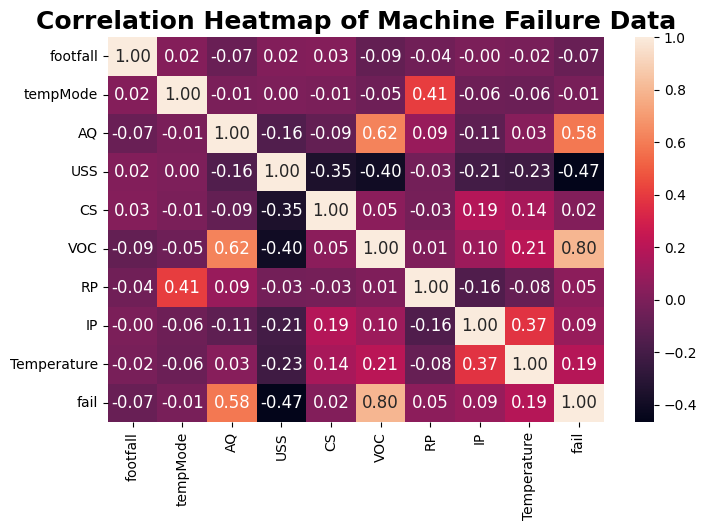

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            annot_kws={"size": 12},
            fmt=".2f")
plt.title('Correlation Heatmap of Machine Failure Data', fontsize=18,fontweight='bold')
plt.show()

In [11]:
# Calculate the correlation matrix and sort the correlations with Fail
correlation_with_fail = df.corr(numeric_only=True).fail.sort_values(ascending=False)

# Display the sorted Fail
print(correlation_with_fail)

fail           1.000000
VOC            0.797329
AQ             0.583238
Temperature    0.190257
IP             0.085624
RP             0.053668
CS             0.018855
tempMode      -0.014462
footfall      -0.073066
USS           -0.466574
Name: fail, dtype: float64


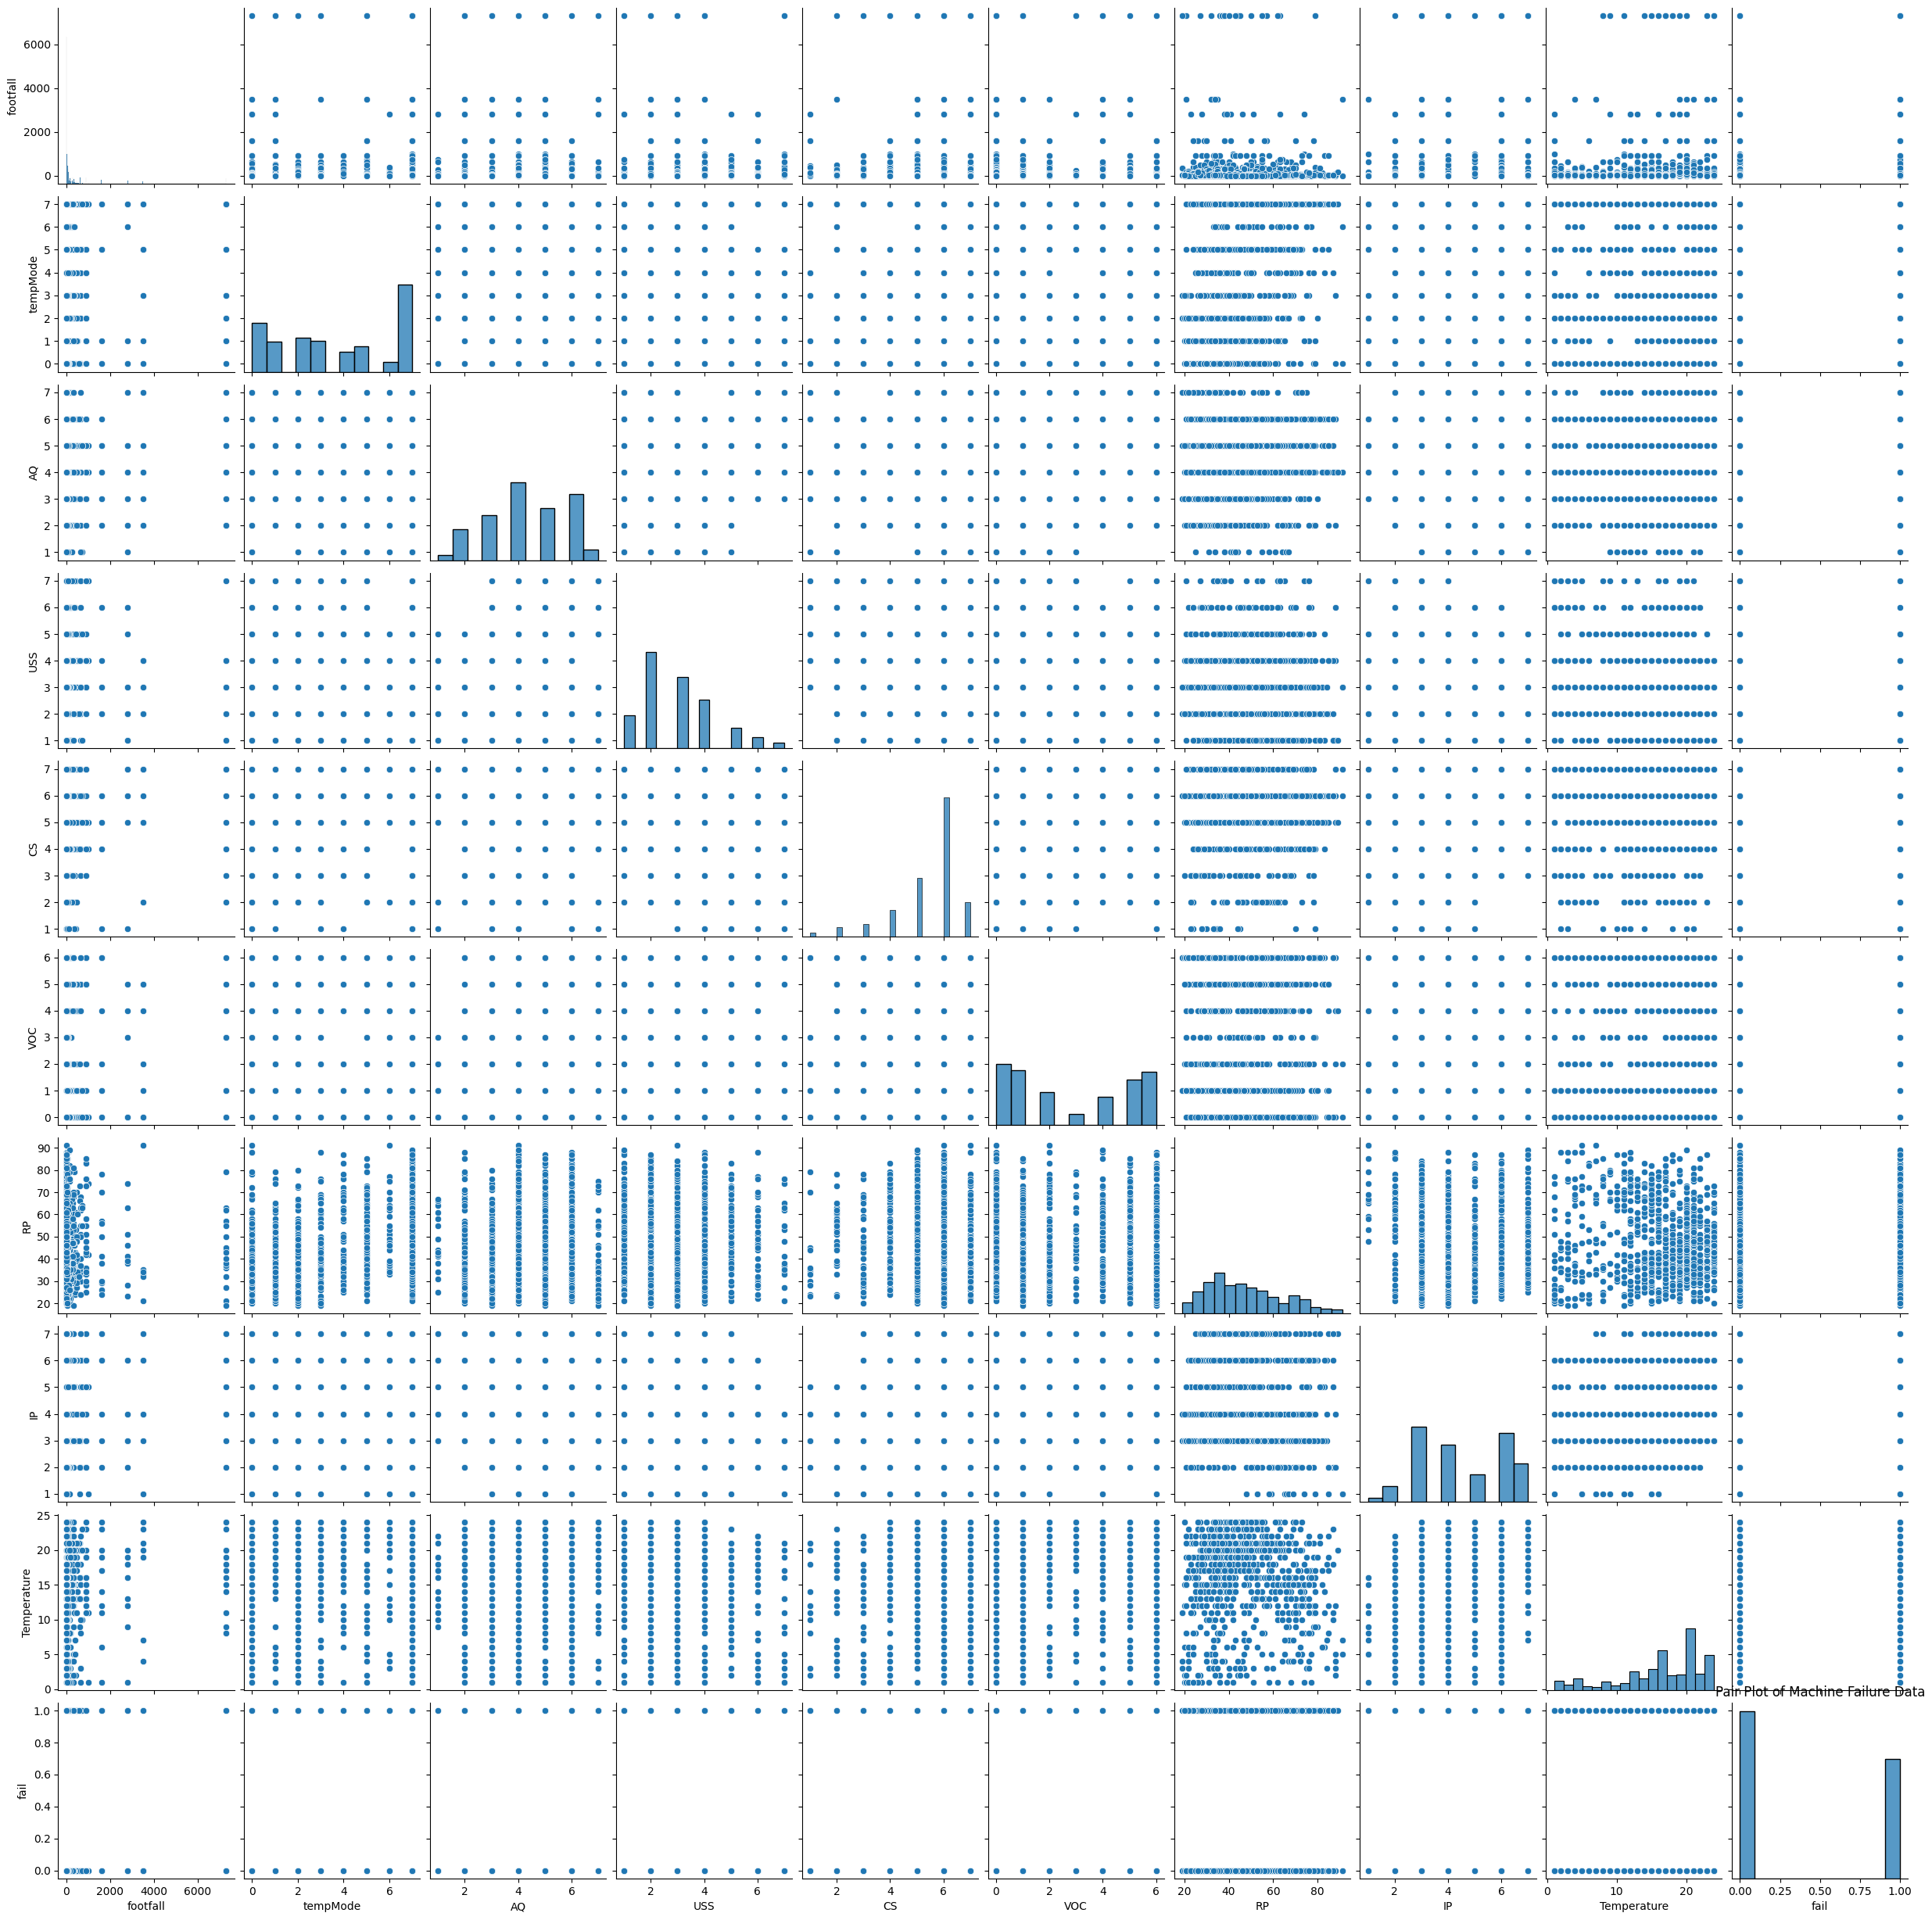

In [12]:
sns.pairplot(df)
plt.title('Pair Plot of Machine Failure Data')
plt.show()

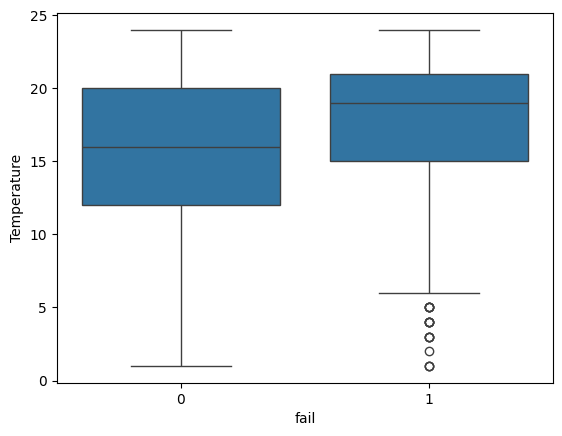

In [13]:
sns.boxplot(x='fail', y='Temperature', data=df)
plt.show()

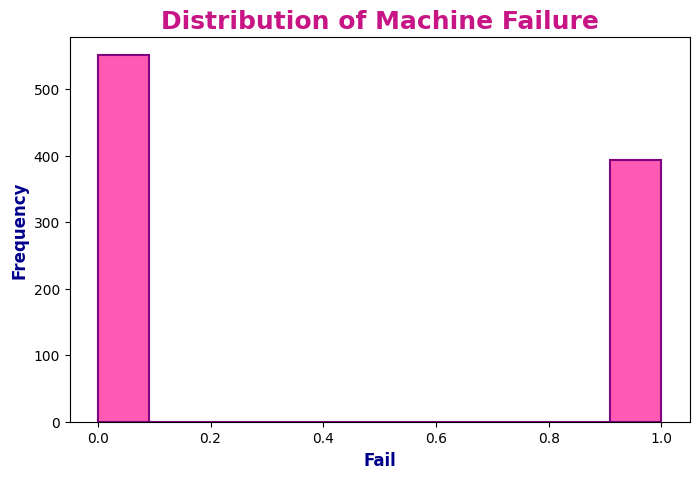

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['fail'],color='deeppink',edgecolors='purple',linewidth=1.5, alpha=0.7)
plt.xlabel("Fail", fontsize=12, color='darkblue', fontweight='semibold')
plt.ylabel("Frequency", fontsize=12, color='darkblue', fontweight='semibold')
plt.title("Distribution of Machine Failure", fontsize=18, color='mediumvioletred', fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## **Model Training**

In [15]:
X = df.drop('fail', axis=1)
y = df['fail']

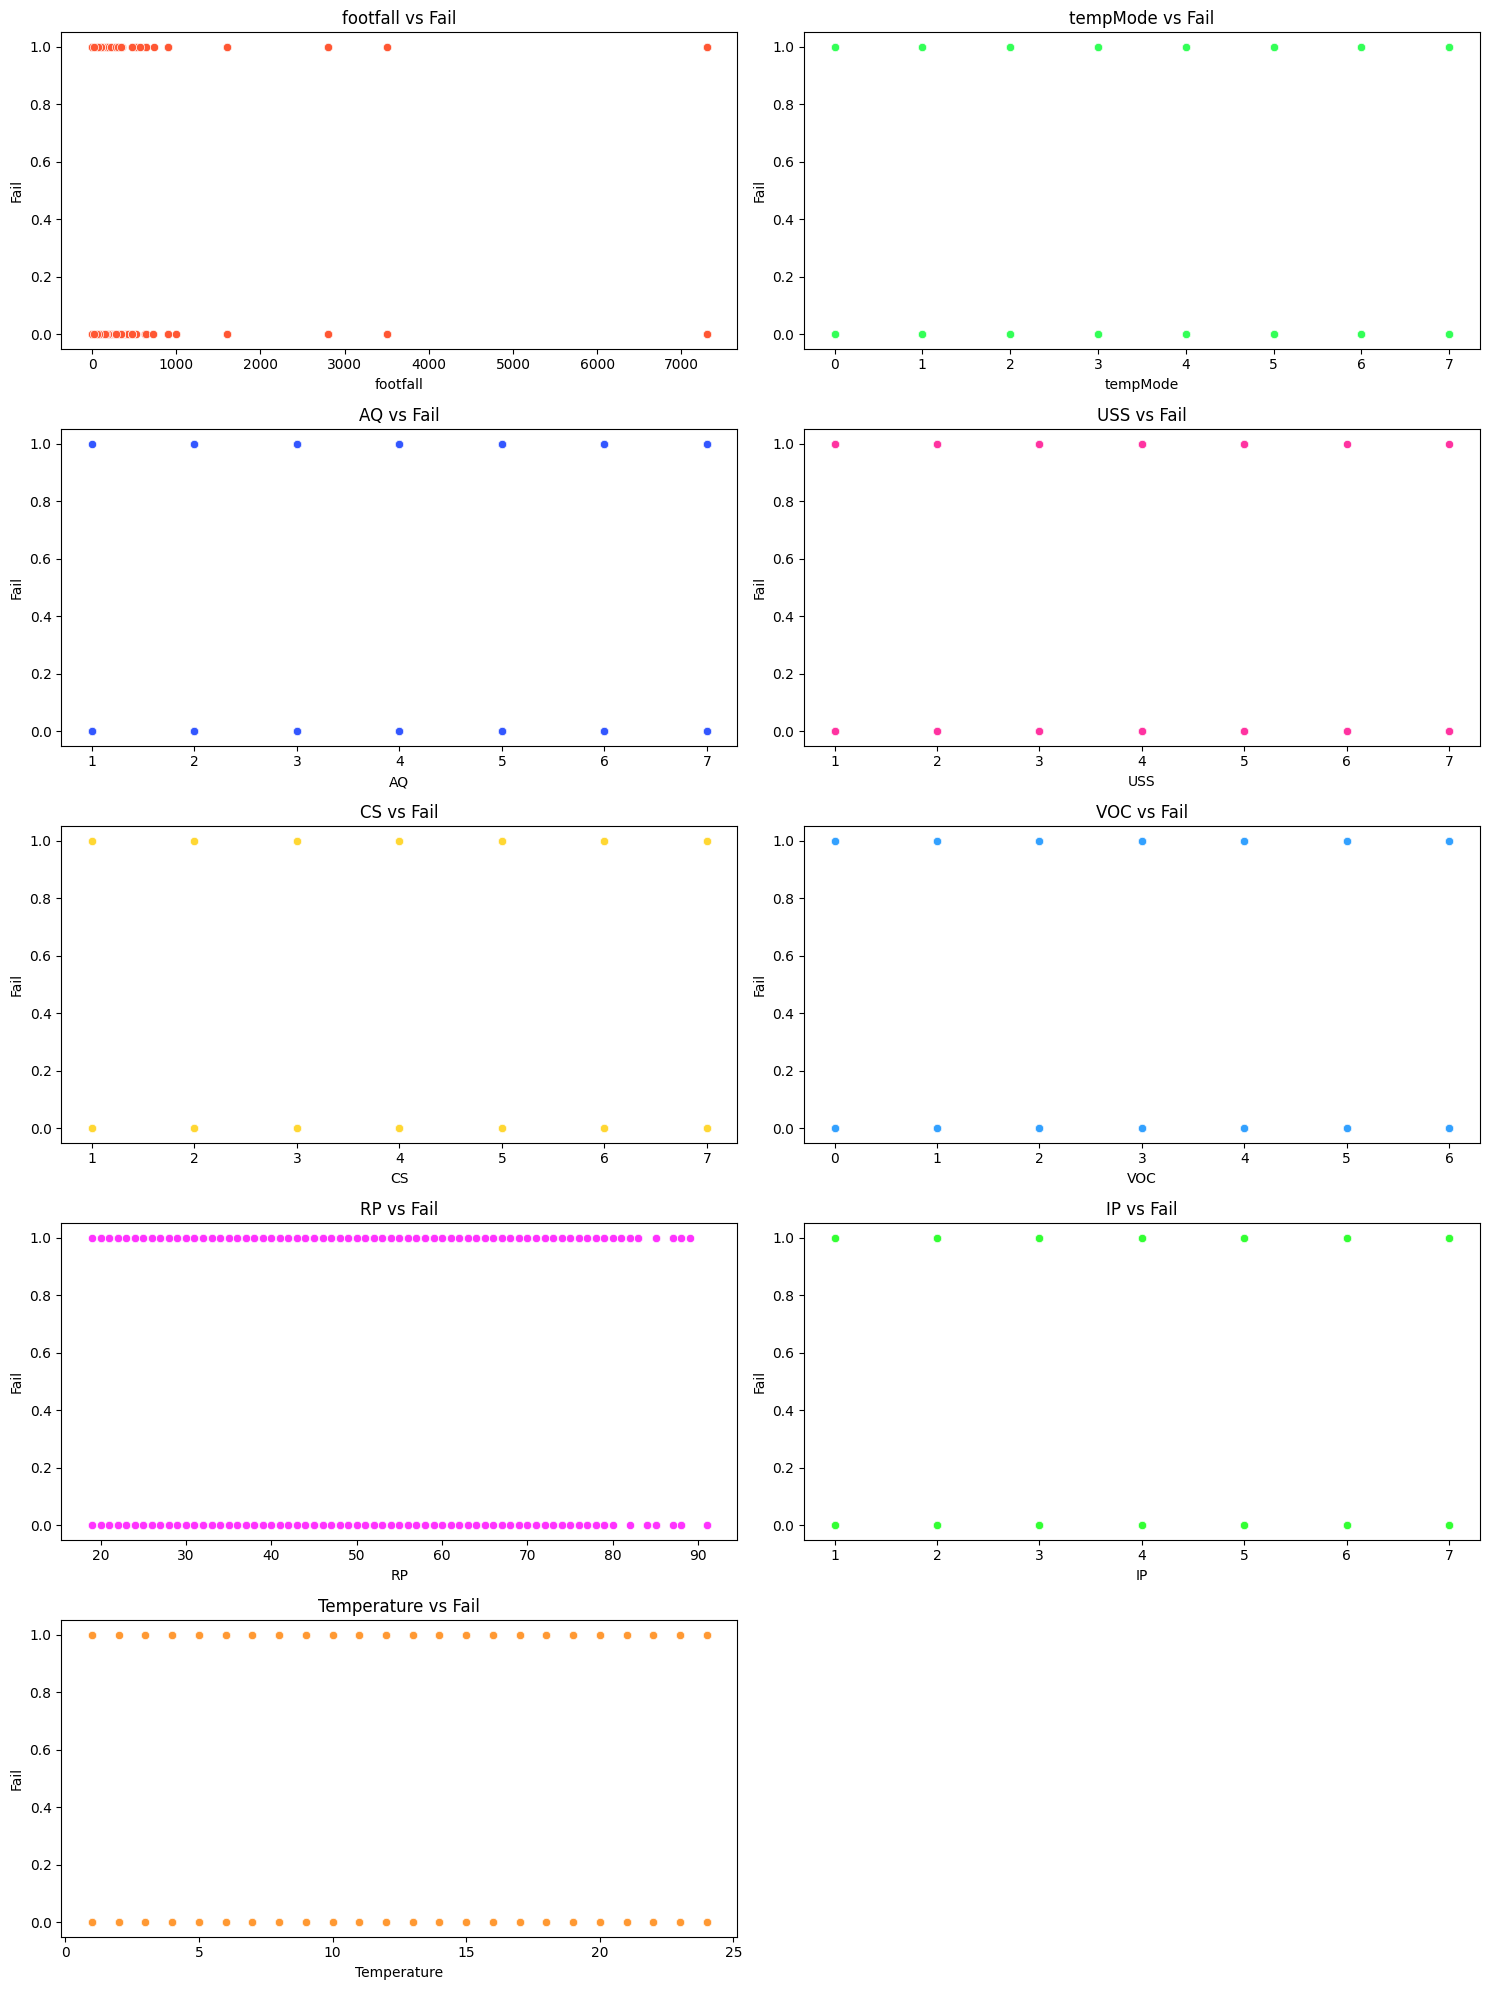

In [16]:
# Visualise the relationship between the features and the response using scatterplots
# Define the variables and colors
x_vars = ['footfall','tempMode','AQ','USS','CS','VOC','RP','IP','Temperature']
colors = ['#FF5733',  # Red-Orange
          '#33FF57',  # Green
          '#3357FF',  # Blue
          '#FF33A1',  # Pink
          '#FFD733',  # Yellow
          '#33A1FF',  # Light Blue
          '#FF33FF',  # Magenta
          '#33FF33',  # Lime Green
          '#FF9933']  # Orange

# Create a figure and axes
fig, axes = plt.subplots(5,2, figsize=(15,20))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Create individual scatter plots
for ax, var, color in zip(axes, x_vars, colors):
    sns.scatterplot(x=df[var], y=df['fail'], ax=ax, color=color)
    ax.set_title(f'{var} vs Fail')
    ax.set_xlabel(var)
    ax.set_ylabel('Fail')

# Remove any empty subplots if there are more axes than variables
for i in range(len(x_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [17]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler()
X = pd.DataFrame(pre_process.fit_transform(X))

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(660, 9)
(284, 9)
(660,)
(284,)


In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
# Print model accuracy
print(f"Model Accuracy: {lr.score(X_test,y_test)*100}%")

Model Accuracy: 91.90140845070422%


In [23]:
# print the intercept
print(lr.intercept_)

[-0.53203128]


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [25]:
# Print model accuracy
print(f"Model Accuracy: {rf.score(X_test,y_test)*100}%")

Model Accuracy: 92.95774647887323%


In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=5,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
# Print model accuracy
print(f"Model Accuracy: {xgb.score(X_test,y_test)*100}%")

Model Accuracy: 91.19718309859155%


In [28]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       166
           1       0.87      0.95      0.91       118

    accuracy                           0.92       284
   macro avg       0.91      0.92      0.92       284
weighted avg       0.92      0.92      0.92       284

ROC-AUC: 0.9742699612007352

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       166
           1       0.90      0.93      0.92       118

    accuracy                           0.93       284
   macro avg       0.93      0.93      0.93       284
weighted avg       0.93      0.93      0.93       284

ROC-AUC: 0.9802685317541352

XGBoost
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       166
           1       0.87      0.92      0.90       118

    accuracy                           0.91       284
   macro avg       0.91    

In [29]:
predictions = lr.predict(X_test)

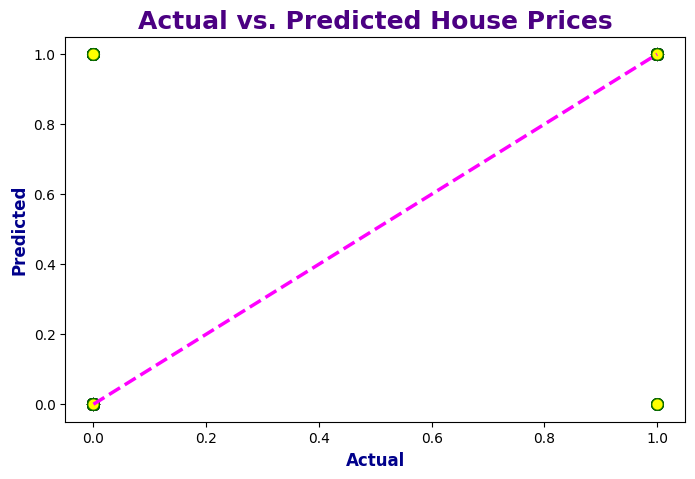

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,predictions,color='yellow', alpha=0.8, edgecolors='darkgreen', linewidths=1, s=70)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='magenta', linestyle='--', linewidth=2.5)
plt.xlabel("Actual", fontsize=12, color='darkblue', fontweight='semibold')
plt.ylabel("Predicted", fontsize=12, color='darkblue', fontweight='semibold')
plt.title("Actual vs. Predicted House Prices", fontsize=18, color='indigo', fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

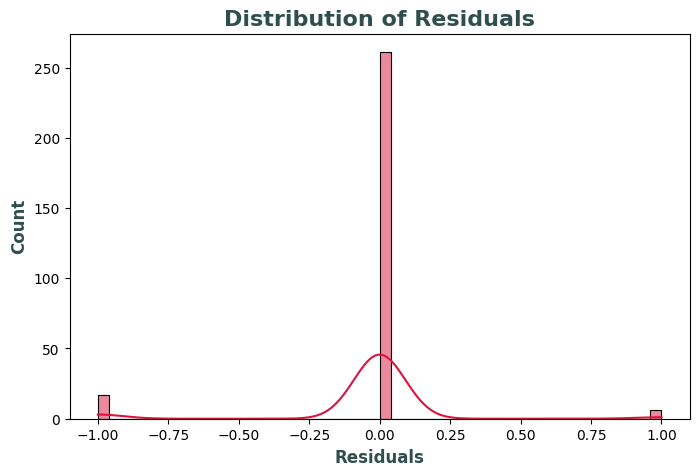

In [31]:
plt.figure(figsize=(8,5))
sns.histplot((y_test - predictions), bins=50, color='crimson', kde=True)
plt.title("Distribution of Residuals", fontsize=16, color='darkslategray', fontweight='bold')
plt.xlabel("Residuals", fontsize=12, color='darkslategray',fontweight='bold')
plt.ylabel("Count", fontsize=12, color='darkslategray',fontweight='bold')
plt.show()

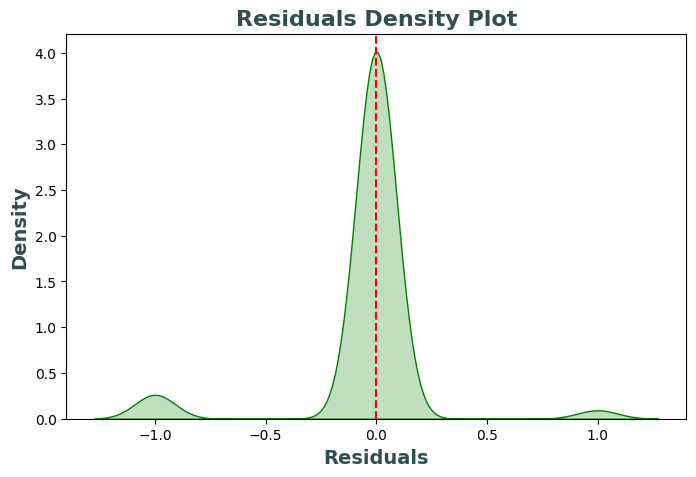

In [32]:
residuals = y_test - predictions
plt.figure(figsize=(8,5))
sns.kdeplot(residuals, fill=True, color='green')
plt.axvline(x=0, color='red', linestyle='dashed')
plt.xlabel('Residuals', fontsize=14,color='darkslategray',fontweight='bold')
plt.ylabel('Density', fontsize=14,color='darkslategray',fontweight='bold')
plt.title('Residuals Density Plot', fontsize=16,color='darkslategray',fontweight='bold')
plt.show()

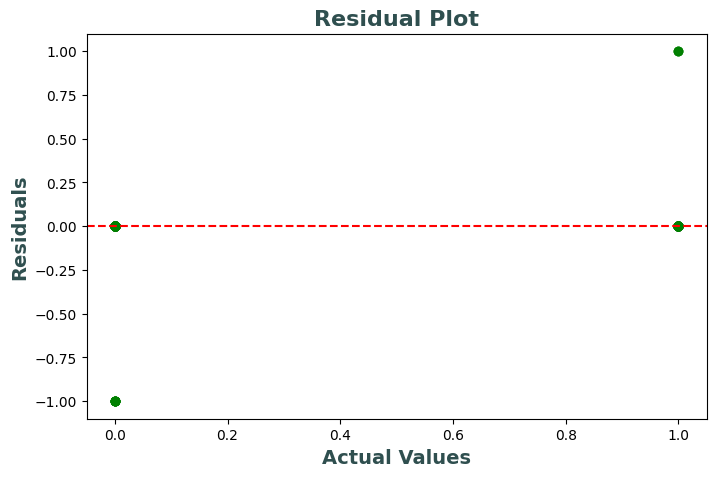

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='dashed')
plt.xlabel('Actual Values', fontsize=14,color='darkslategray',fontweight='bold')
plt.ylabel('Residuals', fontsize=14,color='darkslategray',fontweight='bold')
plt.title('Residual Plot', fontsize=16,color='darkslategray',fontweight='bold')
plt.show()

In [34]:
from sklearn import metrics
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, predictions)
print(f"MAPE: {mape * 100:.2f}%")

MAPE: 26958166783555784.00%


In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions)
print(f"R-squared(R2): {r2 * 100:.2f}%")

R-squared(R2): 66.65%


In [36]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
mean_cv_r2 = np.mean(cv_scores)
print(f"Cross-Validation R2 Score: {mean_cv_r2 * 100:.2f}%")

Cross-Validation R2 Score: 58.57%


In [37]:
original_feature_names = df.drop('fail', axis=1).columns
coeff_df = pd.DataFrame(lr.coef_.T, index=original_feature_names, columns=['Coefficient'])
coeff_df

,Coefficient
footfall,-0.161992
tempMode,-0.036455
AQ,0.793656
USS,-1.171272
CS,-0.577072
VOC,2.196243
RP,0.179910
IP,0.133132
Temperature,0.156906


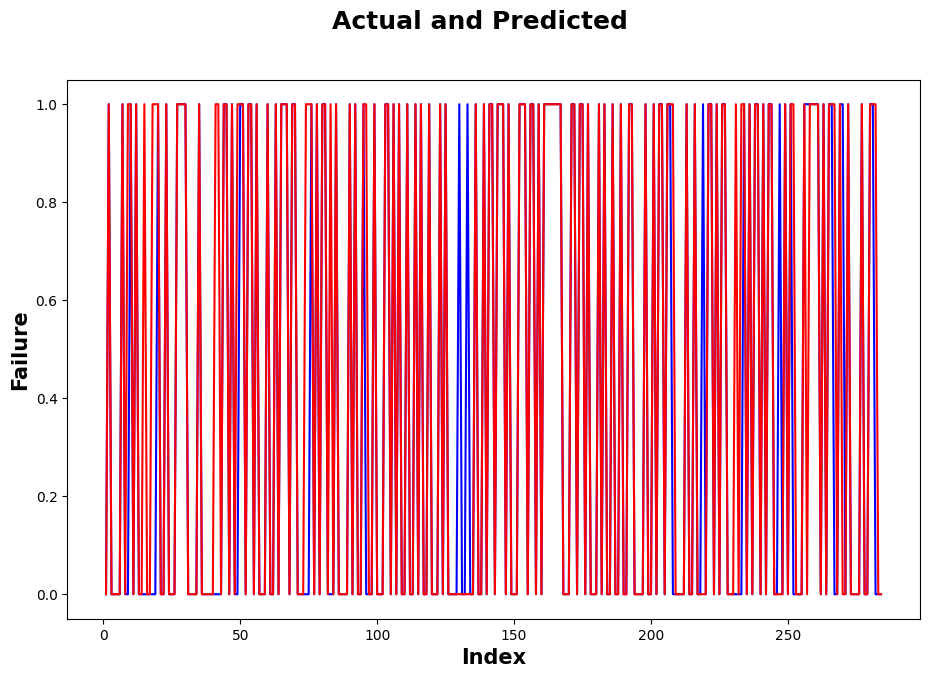

In [38]:
# Actual and Predicted
c = [i for i in range(1, len(y_test) + 1, 1)] # generating index
fig = plt.figure(figsize=(11,7))
plt.plot(c,y_test, color="blue", linewidth=1.5, linestyle="-") #Plotting Actual
plt.plot(c,predictions, color="red",  linewidth=1.5, linestyle="-") #Plotting predicted
fig.suptitle('Actual and Predicted', fontsize=18, fontweight='bold')              # Plot heading
plt.xlabel('Index', fontsize=15, fontweight='semibold')                               # X-label
plt.ylabel('Failure', fontsize=15, fontweight='semibold')                       # Y-label
plt.show()

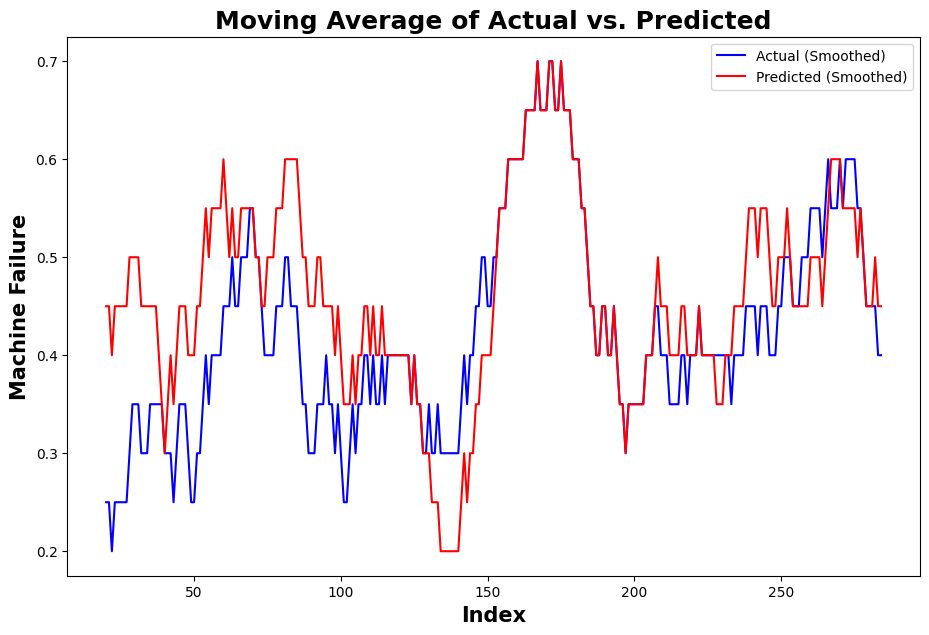

In [41]:
plt.figure(figsize=(11,7))
plt.plot(c, pd.Series(y_test).rolling(window=20).mean(), color="blue", label="Actual (Smoothed)")
plt.plot(c, pd.Series(predictions).rolling(window=20).mean(), color="red", label="Predicted (Smoothed)")
plt.legend()
plt.xlabel('Index', fontsize=15,fontweight='semibold')
plt.ylabel('Machine Failure', fontsize=15,fontweight='semibold')
plt.title('Moving Average of Actual vs. Predicted', fontsize=18,fontweight='bold')
plt.show()

- Blue (Actual) vs. Red (Predicted) Values: A good model should have the red line closely following the blue line.

- Overall Fit of the Model: The predicted values (red) seem to match the actual values (blue) reasonably well. However, there are noticeable deviations, indicating prediction errors.

- Variance in Predictions: Some predictions are very close to actual values, but some show significant differences.The spread suggests that the model captures trends but still has room for improvement.

- Possible Overfitting or Underfitting: If the red (predicted) line deviates significantly in some regions, the model might be underfitting. If the predictions fluctuate excessively, it might indicate overfitting.

- Next Steps for Model Improvement: Check residual errors and distribution. Try improving feature selection or using more advanced models like Polynomial Regression or Random Forest. Experiment with hyperparameter tuning to enhance accuracy.

In [40]:
dummy_data = {
    'footfall': 2700,
    'tempMode': 0,
    'AQ': 5,
    'USS': 3,
    'CS': 5,
    'VOC': 2,
    'RP': 52,
    'IP': 6,
    'Temperature': 20}

dummy_df = pd.DataFrame([dummy_data])

# Apply the same preprocessing as training data
scaled_dummy = pd.DataFrame(pre_process.transform(dummy_df), columns=dummy_df.columns)

# Predict the price
predicted_failure = lr.predict(scaled_dummy.values)
print(f"Predicted Machine Failure: {predicted_failure[0]}")

Predicted Machine Failure: 0
